In [1]:
import pandas as pd 
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
def load_hyperparameters(json_path: str):
    """
    Load hyperparameters from a JSON file and return them as variables.
    """
    with open(json_path, "r") as f:
        params = json.load(f)

    # Map JSON keys to variable names you’ll use later
    hidden_dim    = params.get("hidden_dim")
    learning_rate = params.get("learning_rate")
    epochs        = params.get("epochs")
    dropout       = params.get("dropout")
    batch_size    = params.get("batch_size")
    n_heads       = params.get("num_heads")
    weight_decay  = params.get("weight_decay")

    print(f"Loaded hyperparameters from {json_path}:")
    print(f"  hidden_dim: {hidden_dim}")
    print(f"  learning_rate: {learning_rate}")
    print(f"  epochs: {epochs}")
    print(f"  dropout: {dropout}")
    print(f"  batch_size: {batch_size}")
    print(f"  n_heads: {n_heads}")
    print(f"  weight_decay: {weight_decay}")
    return hidden_dim, learning_rate, epochs, dropout, batch_size, n_heads, weight_decay

In [8]:
# Best result model path
path_val_results = "../Results/Safetorch/TEST_RGCN_noCRoss_sisampler_recall/analyzed_validation_results.csv"
path_best_params = "../Results/Safetorch/TEST_RGCN_noCRoss_sisampler_recall/best_params.json"

In [10]:
# Read the CSV file into a DataFrame
df = pd.read_csv(path_val_results)

In [11]:
# Load hyperparameters from JSON
hidden_dim, learning_rate, epochs, dropout, batch_size, n_heads, weight_decay = \
    load_hyperparameters(path_best_params)

Loaded hyperparameters from ../Results/Safetorch/TEST_RGCN_noCRoss_sisampler_recall/best_params.json:
  hidden_dim: 32
  learning_rate: 0.01
  epochs: 25
  dropout: 0.1
  batch_size: 64
  n_heads: None
  weight_decay: 0.01


In [13]:
# Or Load hyperparameters from manually set values
hidden_dim = 32
learning_rate = 0.01
epochs = 25
dropout = 0.1
batch_size = 64
#n_heads = None
weight_decay = 0.01

In [14]:
# Filter the data based on specific hyperparameters
mask = (df['hidden_dim'] == hidden_dim) & (df['dropout'] == dropout) & \
        (df['epochs'] == epochs )  & \
        (df['learning_rate'] == learning_rate ) & \
        (df['batch_size'] == batch_size) &  (df['weight_decay'] == weight_decay) #& \
        #(df['num_heads'] == n_heads) # Comment / Uncomment for GAT / GCN and GraphSAGE

# Filter the DataFrame based on the mask
filtered_df = df[mask]

In [15]:
filtered_df.head()

,filename,name,address,node_shape,edge_shape,true_label,prediction,parser_probability,dataset_len,hidden_dim,dropout,learning_rate,epochs,batch_size,weight_decay,num_heads
497280,picohttpparser_3_32.pt,sym.test_chunked_consume_trailer,0x804a260,"(11, 100)","(2, 16)",0,1,0.576533,760,32,0.1,0.01,25,64,0.01,1
497281,picohttpparser_3_32.pt,sym.test_chunked_at_once,0x804aa20,"(32, 100)","(2, 44)",0,1,0.601822,760,32,0.1,0.01,25,64,0.01,1
497282,picohttpparser_3_32.pt,sym.test_chunked_leftdata,0x804a320,"(15, 100)","(2, 20)",0,0,0.454090,760,32,0.1,0.01,25,64,0.01,1
497283,picohttpparser_3_32.pt,sym.note,0x804a020,"(11, 100)","(2, 13)",0,0,0.442498,760,32,0.1,0.01,25,64,0.01,1
497284,picohttpparser_3_32.pt,sym.phr_decode_chunked,0x8049d00,"(6, 100)","(2, 5)",1,0,0.113611,760,32,0.1,0.01,25,64,0.01,1


In [16]:
# Remove the columns hidden_dim, dropout, learning_rate, epochs, batch_size, weight_decay, num_heads
filtered_df = filtered_df.drop(columns=['hidden_dim', 'dropout', 'learning_rate', 'epochs', 'batch_size', 'weight_decay', 'num_heads'])
filtered_df.head()

,filename,name,address,node_shape,edge_shape,true_label,prediction,parser_probability,dataset_len
497280,picohttpparser_3_32.pt,sym.test_chunked_consume_trailer,0x804a260,"(11, 100)","(2, 16)",0,1,0.576533,760
497281,picohttpparser_3_32.pt,sym.test_chunked_at_once,0x804aa20,"(32, 100)","(2, 44)",0,1,0.601822,760
497282,picohttpparser_3_32.pt,sym.test_chunked_leftdata,0x804a320,"(15, 100)","(2, 20)",0,0,0.454090,760
497283,picohttpparser_3_32.pt,sym.note,0x804a020,"(11, 100)","(2, 13)",0,0,0.442498,760
497284,picohttpparser_3_32.pt,sym.phr_decode_chunked,0x8049d00,"(6, 100)","(2, 5)",1,0,0.113611,760


In [17]:
# Get unique dataset lengths in the filtered DataFrame
filtered_df.dataset_len.unique()

array([ 760, 1802,  362,  421, 2293,  653,  252,  679,  382,  294])

## TESTS

In [18]:
print(f"Total samples in PicoHTTPParser: {filtered_df[filtered_df.dataset_len==760].shape[0]}")
print(f"Total samples in CSimpleJSONParser: {filtered_df[filtered_df.dataset_len==653].shape[0]}")
print(f"Total samples in Benoitc_HTTP: {filtered_df[filtered_df.dataset_len==421].shape[0]}")
print(f"Total samples in CParserXML: {filtered_df[filtered_df.dataset_len==362].shape[0]}")
print(f"Total samples in cJSON_Parser: {filtered_df[filtered_df.dataset_len==2293].shape[0]}")
print(f"Total samples in YACC_Calculator: {filtered_df[filtered_df.dataset_len==252].shape[0]}")
print(f"Total samples in ELF_Parser: {filtered_df[filtered_df.dataset_len==679].shape[0]}")
print(f"Total samples in Network_Packet_Analyzer: {filtered_df[filtered_df.dataset_len==382].shape[0]}")
print(f"Total samples in Packcc: {filtered_df[filtered_df.dataset_len==1802].shape[0]}")
print(f"Total samples in PCAP_Parser: {filtered_df[filtered_df.dataset_len==294].shape[0]}")


Total samples in PicoHTTPParser: 760
Total samples in CSimpleJSONParser: 653
Total samples in Benoitc_HTTP: 421
Total samples in CParserXML: 362
Total samples in cJSON_Parser: 2293
Total samples in YACC_Calculator: 252
Total samples in ELF_Parser: 679
Total samples in Network_Packet_Analyzer: 382
Total samples in Packcc: 1802
Total samples in PCAP_Parser: 294


In [19]:
print(f"Total predicted label 1 in PicoHTTPParser: {sum(filtered_df[filtered_df.dataset_len==760].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==760].prediction)/filtered_df[filtered_df.dataset_len==760].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in CSimpleJSONParser: {sum(filtered_df[filtered_df.dataset_len==653].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==653].prediction)/filtered_df[filtered_df.dataset_len==653].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in Benoitc_HTTP: {sum(filtered_df[filtered_df.dataset_len==421].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==421].prediction)/filtered_df[filtered_df.dataset_len==421].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in CParserXML: {sum(filtered_df[filtered_df.dataset_len==362].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==362].prediction)/filtered_df[filtered_df.dataset_len==362].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in cJSON_Parser: {sum(filtered_df[filtered_df.dataset_len==2293].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==2293].prediction)/filtered_df[filtered_df.dataset_len==2293].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in YACC_Calculator: {sum(filtered_df[filtered_df.dataset_len==252].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==252].prediction)/filtered_df[filtered_df.dataset_len==252].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in ELF_Parser: {sum(filtered_df[filtered_df.dataset_len==679].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==679].prediction)/filtered_df[filtered_df.dataset_len==679].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in Network_Packet_Analyzer: {sum(filtered_df[filtered_df.dataset_len==382].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==382].prediction)/filtered_df[filtered_df.dataset_len==382].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in Packcc: {sum(filtered_df[filtered_df.dataset_len==1802].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==1802].prediction)/filtered_df[filtered_df.dataset_len==1802].shape[0])*100:.2f}%)")
print(f"Total predicted label 1 in PCAP_Parser: {sum(filtered_df[filtered_df.dataset_len==294].prediction)} (% {(sum(filtered_df[filtered_df.dataset_len==294].prediction)/filtered_df[filtered_df.dataset_len==294].shape[0])*100:.2f}%)")   

Total predicted label 1 in PicoHTTPParser: 446 (% 58.68%)
Total predicted label 1 in CSimpleJSONParser: 409 (% 62.63%)
Total predicted label 1 in Benoitc_HTTP: 149 (% 35.39%)
Total predicted label 1 in CParserXML: 128 (% 35.36%)
Total predicted label 1 in cJSON_Parser: 1056 (% 46.05%)
Total predicted label 1 in YACC_Calculator: 156 (% 61.90%)
Total predicted label 1 in ELF_Parser: 454 (% 66.86%)
Total predicted label 1 in Network_Packet_Analyzer: 184 (% 48.17%)
Total predicted label 1 in Packcc: 1276 (% 70.81%)
Total predicted label 1 in PCAP_Parser: 74 (% 25.17%)


# Some stats and plots analysis

In [18]:
import pandas as pd

# Existing utility functions
KNOWN_COMPILERS = {'gcc', 'clang'}

OPT_TOKEN_MAP = {
    '0': 'O0', '1': 'O1', '2': 'O2', '3': 'O3',
    's': 'Os', 'fast': 'Ofast',
    'O0': 'O0', 'O1': 'O1', 'O2': 'O2', 'O3': 'O3',
    'Os': 'Os', 'Ofast': 'Ofast',
}

def parse_filename(fn: str):
    """
    Splits a filename into (program, optimization, compiler).
    """
    base = fn.replace('.pt', '')
    parts = base.split('_')
    settings_idx = None
    for i, tok in enumerate(parts[1:], start=1):
        if tok in KNOWN_COMPILERS or tok in OPT_TOKEN_MAP or tok.isdigit():
            settings_idx = i
            break

    if settings_idx is None:
        program = base
        settings = []
    else:
        program = '_'.join(parts[:settings_idx])
        settings = parts[settings_idx:]

    compiler = next((s for s in settings if s in KNOWN_COMPILERS), 'default')

    # Default to gcc if no compiler found
    if compiler == 'default':
        compiler = 'gcc'  

    opts = []
    for s in settings:
        if s in OPT_TOKEN_MAP:
            opts.append(OPT_TOKEN_MAP[s])
        elif s.isdigit() and s not in OPT_TOKEN_MAP:
            opts.append(s)
    optimization = '_'.join(opts) if opts else 'default'
    return program, optimization, compiler

# Core analysis functions
def compute_setting_counts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Count functions per (optimization, compiler).
    """
    return (
        df
        .groupby(['optimization', 'compiler'])
        .size()
        .reset_index(name='num_functions')
    )

def compute_unique_program_counts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Count distinct programs per (optimization, compiler).
    """
    return (
        df
        .groupby(['optimization', 'compiler'])['program']
        .nunique()
        .reset_index(name='unique_programs')
    )

def compute_setting_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge function-counts and program-counts into a single DataFrame.
    """
    counts = compute_setting_counts(df)
    uniques = compute_unique_program_counts(df)
    return pd.merge(counts, uniques, on=['optimization', 'compiler'])

def compute_distributions(df: pd.DataFrame) -> dict:
    """
    Returns counts per compiler and per optimization.
    """
    return {
        'compiler': df['compiler'].value_counts(),
        'optimization': df['optimization'].value_counts(),
    }

def compute_global_totals(df: pd.DataFrame) -> dict:
    """
    Returns total functions and distinct programs.
    """
    return {
        'total_functions': len(df),
        'total_programs': df['program'].nunique(),
    }

def compute_numeric_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Descriptive statistics for numeric columns.
    """
    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols) == 0:
        return pd.DataFrame()
    return df[numeric_cols].describe()

# New: Filtering and summary function
def summarize_program(df: pd.DataFrame, program_name: str = None) -> None:
    """
    Print a summary of the DataFrame, optionally filtered by program_name.

    Summary includes:
      - Number and list of distinct compilers
      - Number and list of distinct optimizations
      - Total functions per compiler
      - Total functions per optimization
      - Detailed per-setting stats (num functions & unique programs)
    """
    # Optionally filter by program
    if program_name:
        df = df[df['program'] == program_name]
        print(f"\n=== Summary for program: '{program_name}' ===")
    else:
        print("\n=== Summary for all programs ===")

    # Distinct compilers and optimizations
    compilers = sorted(df['compiler'].unique())
    opts = sorted(df['optimization'].unique())
    print(f"Distinct compilers ({len(compilers)}): {compilers}")
    print(f"Distinct optimizations ({len(opts)}): {opts}\n")

    # Totals per compiler and optimization
    comp_dist = df['compiler'].value_counts()
    opt_dist = df['optimization'].value_counts()
    print("Total functions per compiler:")
    print(comp_dist.to_string())
    print("\nTotal functions per optimization:")
    print(opt_dist.to_string())

    # Detailed setting stats
    stats = compute_setting_stats(df)
    print("\nDetailed (optimization, compiler) stats:")
    print(stats.sort_values('num_functions', ascending=False).to_string(index=False))


df = filtered_df.copy()
# Parse filenames and extract program, optimization, compiler
df['program'], df['optimization'], df['compiler'] = zip(*df['filename'].apply(parse_filename))
# Save to csv
df.to_csv('../Results/TEST_GAT_F1/df_results.csv', index=False)
df.head()


,filename,name,address,node_shape,edge_shape,true_label,prediction,parser_probability,dataset_len,program,optimization,compiler
400797,packcc_Os_32_clang.pt,sym.malloc_e,0x8049d22,"(17, 100)","(2, 19)",0,1,0.506808,1802,packcc,Os_32,clang
400798,packcc_Os_32_clang.pt,sym.print_error,0x80483a0,"(7, 100)","(2, 7)",0,0,0.062990,1802,packcc,Os_32,clang
400799,packcc_Os_32_clang.pt,sym.add_fileext,0x8049d4d,"(9, 100)","(2, 10)",0,0,0.456522,1802,packcc,Os_32,clang
400800,packcc_Os_32_clang.pt,sym.replace_fileext,0x8049db7,"(18, 100)","(2, 25)",0,1,0.509932,1802,packcc,Os_32,clang
400801,packcc_Os_32_clang.pt,sym.match_spaces,0x8049e4e,"(17, 100)","(2, 21)",1,1,0.532013,1802,packcc,Os_32,clang


In [19]:
# print unique programs
print("Unique programs in the dataset:")
print(df['program'].unique())

Unique programs in the dataset:
['packcc' 'cjson' 'picohttpparser' 'example' 'http_parser' 'elf-parser'
 'parse_xml' 'pcap_parser' 'network_analyzer' 'calc']


In [20]:
# Summarize a specific program
summarize_program(df, program_name='parse_xml') 


=== Summary for program: 'parse_xml' ===
Distinct compilers (2): ['clang', 'gcc']
Distinct optimizations (14): ['32', 'O0', 'O0_32', 'O1', 'O1_32', 'O2', 'O2_32', 'O3', 'O3_32', 'Ofast', 'Ofast_32', 'Os', 'Os_32', 'default']

Total functions per compiler:
compiler
clang    182
gcc      180

Total functions per optimization:
optimization
O0_32       44
32          44
default     44
O0          44
Os          23
Os_32       23
O1_32       18
Ofast_32    18
O3_32       18
O2_32       18
O1          17
Ofast       17
O2          17
O3          17

Detailed (optimization, compiler) stats:
optimization compiler  num_functions  unique_programs
          32    clang             22                1
          32      gcc             22                1
          O0    clang             22                1
          O0      gcc             22                1
       O0_32    clang             22                1
       O0_32      gcc             22                1
     default    clang         

In [21]:
import pandas as pd

def get_comparable_df(df: pd.DataFrame, program_name: str) -> pd.DataFrame:
    """
    Returns a DataFrame containing only those functions (by 'name')
    for the given `program_name` that appear under *every* combination
    of optimization × compiler, so you can do fair comparisons.
    """
    # 1) Filter to the target program
    prog_df = df[df['program'] == program_name].copy()
    if prog_df.empty:
        raise ValueError(f"No entries found for program '{program_name}'")
    
    # 2) Identify all optimizations and compilers present for this program
    opt_levels = prog_df['optimization'].unique()
    compilers = prog_df['compiler'].unique()
    
    # 3) Total number of (opt × comp) combos we expect
    total_combos = len(opt_levels) * len(compilers)
    
    # 4) For each function name, count how many unique (opt, comp) pairs it has
    combo_counts = (
        prog_df
        .drop_duplicates(subset=['name', 'optimization', 'compiler'])
        .groupby('name')
        .size()
    )
    
    # 5) Keep only those names with exactly total_combos appearances
    valid_names = combo_counts[combo_counts == total_combos].index
    
    # 6) Subset to just those rows
    comparable_df = prog_df[prog_df['name'].isin(valid_names)].copy()
    
    # Optional: sort for readability
    comparable_df.sort_values(['name', 'optimization', 'compiler'], inplace=True)
    comparable_df.reset_index(drop=True, inplace=True)
    
    return comparable_df

In [22]:
# print unique programs
print("Unique programs in the dataset:")
print(df['program'].unique())

Unique programs in the dataset:
['packcc' 'cjson' 'picohttpparser' 'example' 'http_parser' 'elf-parser'
 'parse_xml' 'pcap_parser' 'network_analyzer' 'calc']


In [ ]:
# Get comparable DataFrame for a specific program "program_name"
program_df = get_comparable_df(df, program_name='picohttpparser')
print(f"shape: {program_df.shape}")
program_df.head()


shape: (672, 12)


,filename,name,address,node_shape,edge_shape,true_label,prediction,parser_probability,dataset_len,program,optimization,compiler
0,picohttpparser_32_clang.pt,main,0x804af80,"(27, 100)","(2, 34)",1,0,0.451814,760,picohttpparser,32,clang
1,picohttpparser_32.pt,main,0x804ec3a,"(25, 100)","(2, 32)",1,1,0.539859,760,picohttpparser,32,gcc
2,picohttpparser_0_clang.pt,main,0x403260,"(27, 100)","(2, 34)",1,0,0.399471,760,picohttpparser,O0,clang
3,picohttpparser_0.pt,main,0x407bcb,"(25, 100)","(2, 32)",1,0,0.439229,760,picohttpparser,O0,gcc
4,picohttpparser_0_32_clang.pt,main,0x804af80,"(27, 100)","(2, 34)",1,0,0.451814,760,picohttpparser,O0_32,clang


In [24]:
# For just the program_name entries
summarize_program(program_df, program_name='picohttpparser') 


=== Summary for program: 'picohttpparser' ===
Distinct compilers (2): ['clang', 'gcc']
Distinct optimizations (14): ['32', 'O0', 'O0_32', 'O1', 'O1_32', 'O2', 'O2_32', 'O3', 'O3_32', 'Ofast', 'Ofast_32', 'Os', 'Os_32', 'default']

Total functions per compiler:
compiler
clang    336
gcc      336

Total functions per optimization:
optimization
32          48
O0          48
O0_32       48
O1          48
O1_32       48
O2          48
O2_32       48
O3          48
O3_32       48
Ofast       48
Ofast_32    48
Os          48
Os_32       48
default     48

Detailed (optimization, compiler) stats:
optimization compiler  num_functions  unique_programs
          32    clang             24                1
          32      gcc             24                1
          O0    clang             24                1
          O0      gcc             24                1
       O0_32    clang             24                1
       O0_32      gcc             24                1
          O1    clang    

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_accuracy(program_df):
    """
    Plots accuracy for each (optimization, compiler) combination in program_df,
    with a horizontal line showing the mean recall.
    """
    # Compute accuracy by (optimization, compiler)
    acc_series = program_df.groupby(['optimization', 'compiler']).apply(
        lambda g: (g['prediction'] == g['true_label']).mean()
    )
    acc_df = acc_series.reset_index(name='accuracy')
    
    # Compute mean recall (overall accuracy mean)
    mean_acc = acc_df['accuracy'].mean()

    # Pivot to wide format for grouped bar chart
    pivot = acc_df.pivot(index='optimization', columns='compiler', values='accuracy')
    optimizations = pivot.index.tolist()
    compilers = pivot.columns.tolist()
    
    # Plot grouped bar chart
    x = np.arange(len(optimizations))
    width = 0.8 / len(compilers)
    
    fig, ax = plt.subplots()
    for i, compiler in enumerate(compilers):
        ax.bar(x + i * width, pivot[compiler], width, label=compiler)
    
    # Add mean accuracy line
    ax.axhline(mean_acc, linestyle='--')
    ax.text(x[-1] + width, mean_acc, f"Mean: {mean_acc:.2f}", va='bottom')

    # Formatting
    ax.set_xticks(x + width * (len(compilers) - 1) / 2)
    ax.set_xticklabels(optimizations, rotation=45, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy by Optimization and Compiler')
    ax.legend(title='Compiler')
    plt.tight_layout()
    plt.show()

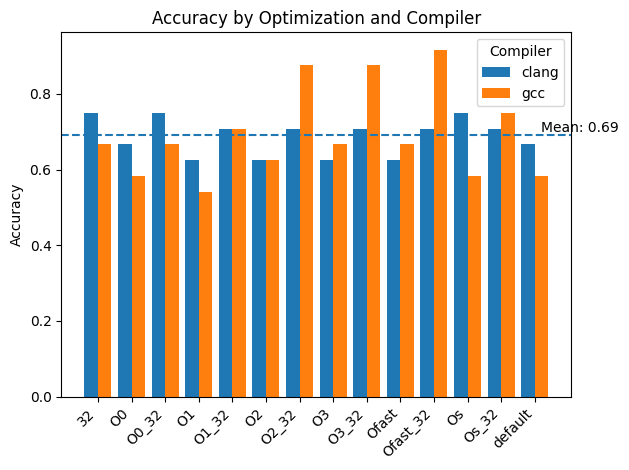

In [26]:
# Plot Accuracy per (optimization, compiler)
plot_accuracy(program_df)

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_recall(program_df):
    """
    Plots recall for each (optimization, compiler) combination in program_df,
    with a horizontal line showing the mean recall.
    """
    # Compute recall by (optimization, compiler)
    def recall(group):
        y_true = group['true_label']
        y_pred = group['prediction']
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        actual_positives = (y_true == 1).sum()
        return tp / actual_positives if actual_positives > 0 else 0.0

    recall_series = program_df.groupby(['optimization', 'compiler']).apply(recall)
    recall_df = recall_series.reset_index(name='recall')
    
    # Compute mean recall
    mean_recall = recall_df['recall'].mean()

    # Pivot to wide format for grouped bar chart
    pivot = recall_df.pivot(index='optimization', columns='compiler', values='recall')
    optimizations = pivot.index.tolist()
    compilers = pivot.columns.tolist()
    
    # Plot grouped bar chart
    x = np.arange(len(optimizations))
    width = 0.8 / len(compilers)  # total bar width <= 0.8
    
    fig, ax = plt.subplots()
    for i, compiler in enumerate(compilers):
        ax.bar(x + i * width, pivot[compiler], width, label=compiler)
    
    # Add mean recall line
    ax.axhline(mean_recall, linestyle='--')
    ax.text(x[-1] + width, mean_recall, f"Mean: {mean_recall:.2f}", va='bottom')

    # Formatting
    ax.set_xticks(x + width * (len(compilers) - 1) / 2)
    ax.set_xticklabels(optimizations, rotation=45, ha='right')
    ax.set_ylabel('Recall')
    ax.set_title('Recall by Optimization and Compiler')
    ax.legend(title='Compiler')
    plt.tight_layout()
    plt.show()


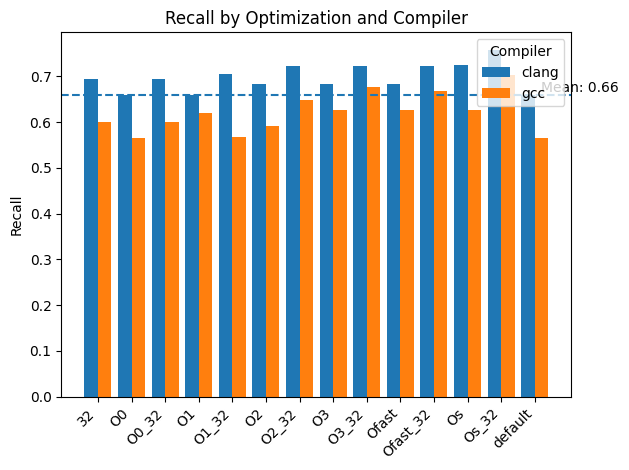

In [36]:
# Plot Recall per (optimization, compiler)
plot_recall(program_df)